# PINN-3 — Multi-Seed Stability Analysis

This notebook re-trains the **PINN-3 (Penman / Priestley–Taylor)** model with several
random seeds while keeping everything else identical. The goal is to estimate the
**variance of test metrics across initialisations**, so that we can report
mean ± std for RMSE, correlation and R² rather than a single-run number.

This is the experiment the thesis defence will want to see.  It directly addresses
the *"one seed — no statistics"* limitation noted in the discussion.

**What stays fixed across runs:**
- Architecture (`EnergyPINN3` from `pinn3_energy.py`)
- Hyper-parameters: `BATCH_SIZE=16`, `LR=3e-4`, `EPOCHS=300`, `SEQ_LEN=6`,
  `LAMBDA_PHYS=1.0`, `PATIENCE=50`
- Chronological train/test split: train ≤ 2017, test 2018–2026
- Data normalisation statistics (computed once on the full series)

**What varies between runs:**
- `torch.manual_seed`, `numpy.random.seed`, `random.seed`
- That seed drives: model-weight init, DataLoader shuffling and dropout masks


## 1. Imports and configuration

In [1]:
import os
import json
import random
import time
import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# Model definition lives in the same folder as this notebook
from pinn3_energy import EnergyPINN3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


In [2]:
# ── Fixed configuration (identical to single-run PINN-3 notebook) ─────
TRAIN_END_YEAR = 2017
BATCH_SIZE     = 16
LR             = 3e-4
EPOCHS         = 300
SEQ_LEN        = 6
LAMBDA_PHYS    = 1.0
PATIENCE       = 50

# ── The thing that actually varies ────────────────────────────────────
# Start with 3 seeds to get a first variance estimate; add more if time allows.
# 5 seeds gives a noticeably more stable mean ± std at ~2x the compute.
SEEDS = [42, 123, 2024, 7, 999]

# ── Paths ─────────────────────────────────────────────────────────────
DATA_PATH  = "merged_grid_dataset_monthly.nc"
VOLGA_PATH = "volga_discharge.csv"
OUT_DIR    = "results/pinn3_multiseed"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"Will run {len(SEEDS)} seeds: {SEEDS}")
print(f"Each run = up to {EPOCHS} epochs (early stopping at patience={PATIENCE})")
print(f"Output dir: {OUT_DIR}")


Will run 5 seeds: [42, 123, 2024, 7, 999]
Each run = up to 300 epochs (early stopping at patience=50)
Output dir: results/pinn3_multiseed


In [3]:
def set_all_seeds(seed: int):
    """Pin every RNG we touch so a given seed is fully reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # Deterministic CuDNN: slower but reproducible.
    # Comment this out if training is too slow and you only need approximate variance.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


## 2. Data loading (run once, shared across seeds)

We load the gridded NetCDF, the Volga discharge CSV and derive the basin/lake-averaged
scalar fluxes that feed the Penman physics loss.  None of this depends on the seed,
so it is computed once and reused by every training run.

In [4]:
# ── Gridded forcings + target ─────────────────────────────────────────
ds = xr.open_dataset(DATA_PATH)
print("Variables in NetCDF:", list(ds.data_vars))
print("Time range:", str(ds.time.values[0])[:10], "→", str(ds.time.values[-1])[:10])

# ── Volga discharge ───────────────────────────────────────────────────
volga_df = pd.read_csv(VOLGA_PATH)
volga_df['time'] = pd.to_datetime(volga_df['time'])
volga_df = volga_df.set_index('time')

# ── Land–sea mask (inside the same NetCDF) ────────────────────────────
lsm_raw = ds.lsm.values
if lsm_raw.ndim == 3:
    lsm_raw = lsm_raw[0]
basin_mask = lsm_raw >  0.5    # land cells   (Volga / Ural basin)
lake_mask  = lsm_raw <= 0.5    # water cells  (Caspian surface)
print(f"Grid {basin_mask.shape}  basin px={basin_mask.sum()}  lake px={lake_mask.sum()}")


Variables in NetCDF: ['u10', 'v10', 'd2m', 't2m', 'snowc', 'sde', 'sd', 'sp', 'swvl1', 'swvl2', 'swvl3', 'swvl4', 'tp', 'e', 'ssr', 'str', 'Qs_acc', 'Qsb_acc', 'SWE_inst', 'water_level', 'delta_water_level', 'lsm']
Time range: 1993-01-01 → 2025-12-01
Grid (110, 90)  basin px=5506  lake px=4394


In [5]:
def basin_avg(field, mask):
    return field.where(mask).mean(dim=['latitude', 'longitude']).to_series().fillna(0)

# Basin-side scalars (runoff side of the physics) ───────────────────────
P_basin   = basin_avg(ds.tp, basin_mask)
PET_basin = (basin_avg(ds.ssr, basin_mask) / 2.5e9).clip(lower=1e-3)

# Lake-side scalars (Penman drivers) ───────────────────────────────────
P_lake     = basin_avg(ds.tp,  lake_mask)
E_lake     = basin_avg(-ds.e,  lake_mask)
T_lake_C   = basin_avg(ds.t2m, lake_mask) - 273.15
Td_lake_C  = basin_avg(ds.d2m, lake_mask) - 273.15
Rn_lake_eq = (basin_avg(ds.ssr, lake_mask) + basin_avg(ds.str, lake_mask)) / 2.5e9
U_lake     = np.sqrt(basin_avg(ds.u10, lake_mask)**2 + basin_avg(ds.v10, lake_mask)**2)
P_kpa_lake = basin_avg(ds.sp, lake_mask) / 1000.0

# Target
water_level = ds.water_level.to_series().ffill().fillna(0)
delta_h     = water_level.diff().fillna(0)

print(f"P_basin   mean={P_basin.mean():.4f}  PET_basin mean={PET_basin.mean():.4f}")
print(f"P_lake    mean={P_lake.mean():.4f}   E_lake    mean={E_lake.mean():.4f}")
print(f"T_lake    mean={T_lake_C.mean():.2f}°C  Rn_lake_eq mean={Rn_lake_eq.mean():.4f}")
print(f"U_lake    mean={U_lake.mean():.2f} m/s  P_kpa mean={P_kpa_lake.mean():.2f} kPa")


P_basin   mean=0.0377  PET_basin mean=0.1489
P_lake    mean=0.0255   E_lake    mean=0.0853
T_lake    mean=14.95°C  Rn_lake_eq mean=0.0984
U_lake    mean=1.91 m/s  P_kpa mean=101.82 kPa


## 3. Dataset and split (identical to single-run notebook)

In [6]:
class EnergyDataset(Dataset):
    GRID_VARS = ['tp', 't2m', 'ssr', 'str', 'sp', 'e', 'd2m',
                 'u10', 'v10', 'Qs_acc', 'Qsb_acc', 'SWE_inst']

    def __init__(self, ds, volga_df, seq_len=6, stats=None):
        self.times   = ds.time.values
        self.seq_len = seq_len

        data_list = [ds[v].values for v in self.GRID_VARS]
        volga_vals = []
        for t in ds.time.values:
            t_dt = pd.to_datetime(t)
            try:
                q = volga_df.loc[t_dt:t_dt]['volga_q'].values[0]
            except Exception:
                q = 8000.0
            volga_vals.append(np.full_like(data_list[0][0], q, dtype=np.float32))
        data_list.append(np.array(volga_vals))
        self.data = np.stack(data_list, axis=1)

        self.targets   = delta_h.values
        self.p_basin   = P_basin.values
        self.pet_basin = PET_basin.values
        self.p_lake    = P_lake.values
        self.e_lake    = E_lake.values
        self.T_lake    = T_lake_C.values
        self.Td_lake   = Td_lake_C.values
        self.Rn_lake   = Rn_lake_eq.values
        self.U_lake    = U_lake.values
        self.P_kpa     = P_kpa_lake.values

        if stats is None:
            self.stats = {
                'mean': np.nanmean(self.data, axis=(0, 2, 3), keepdims=True),
                'std':  np.nanstd(self.data,  axis=(0, 2, 3), keepdims=True),
            }
            self.target_mean = float(np.mean(self.targets))
            self.target_std  = float(np.std(self.targets))
        else:
            self.stats       = stats
            self.target_mean = stats['target_mean']
            self.target_std  = stats['target_std']

        self.data = np.nan_to_num((self.data - self.stats['mean']) /
                                  (self.stats['std'] + 1e-8))
        self.targets_raw  = self.targets
        self.targets_norm = (self.targets - self.target_mean) / (self.target_std + 1e-8)

        self.valid_indices = [i for i in range(len(self.times)) if i >= seq_len - 1]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        i = self.valid_indices[idx]
        x = self.data[i - self.seq_len + 1 : i + 1]
        return (
            torch.FloatTensor(x),
            torch.FloatTensor([self.targets_norm[i]]),
            torch.FloatTensor([self.targets_raw[i]]),
            torch.FloatTensor([self.p_basin[i]]),
            torch.FloatTensor([self.pet_basin[i]]),
            torch.FloatTensor([self.p_lake[i]]),
            torch.FloatTensor([self.e_lake[i]]),
            torch.FloatTensor([self.T_lake[i]]),
            torch.FloatTensor([self.Td_lake[i]]),
            torch.FloatTensor([self.Rn_lake[i]]),
            torch.FloatTensor([self.U_lake[i]]),
            torch.FloatTensor([self.P_kpa[i]]),
        )

# Build dataset and chronological split — both seed-independent
all_years = pd.to_datetime(ds.time.values).year
full_ds   = EnergyDataset(ds, volga_df, seq_len=SEQ_LEN)

train_indices = [i for i, v in enumerate(full_ds.valid_indices) if all_years[v] <= TRAIN_END_YEAR]
test_indices  = [i for i, v in enumerate(full_ds.valid_indices) if all_years[v] >  TRAIN_END_YEAR]

print(f"Train months: {len(train_indices)} ({all_years.min()}–{TRAIN_END_YEAR})")
print(f"Test  months: {len(test_indices)} ({TRAIN_END_YEAR+1}–{all_years.max()})")

t_mean = full_ds.target_mean
t_std  = full_ds.target_std


Train months: 295 (1993–2017)
Test  months: 96 (2018–2025)


## 4. Training function — one seed end-to-end

`train_one_seed(seed)` reproduces the entire training procedure of the single-run
notebook, but parameterised by the seed.  It returns a dict with the test
predictions and the metrics for that run.

**Important:** every call rebuilds the DataLoaders, the model, the optimiser and
the scheduler from scratch.  That is the only way to make the seed actually
mean something.

In [7]:
def train_one_seed(seed: int, verbose: bool = True):
    set_all_seeds(seed)

    # Loaders depend on the seed because shuffle=True uses the global torch RNG
    g = torch.Generator()
    g.manual_seed(seed)

    train_subset = Subset(full_ds, train_indices)
    test_subset  = Subset(full_ds, test_indices)

    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE,
                              shuffle=True, generator=g)
    test_loader  = DataLoader(test_subset,  batch_size=BATCH_SIZE, shuffle=False)

    # Fresh model / optimiser / scheduler every seed
    model     = EnergyPINN3(in_channels=13, seq_len=SEQ_LEN).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {'data_loss': [], 'phys_loss': [], 'val_loss': [],
               'alpha_PT': [], 'C_wind': [], 'gamma_runoff': []}

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(EPOCHS):
        model.train()
        epoch_data_raw = epoch_phys_raw = 0.0
        epoch_alpha    = epoch_cwind    = epoch_gamma = 0.0

        for batch in train_loader:
            (x, y_norm, y_raw,
             p_b, pet_b, p_l, e_l,
             T_l, Td_l, Rn_l, U_l, Pk_l) = [b.to(DEVICE) for b in batch]

            optimizer.zero_grad()
            dh_pred_norm, alpha_PT, C_wind, gamma_runoff = model(x)
            dh_pred_raw = dh_pred_norm * t_std + t_mean

            loss_data = F.mse_loss(dh_pred_norm, y_norm)
            loss_phys, _ = model.penman_loss(
                dh_pred_raw, alpha_PT, C_wind, gamma_runoff,
                T_l, Td_l, Rn_l, U_l, Pk_l, p_l, p_b, pet_b,
            )
            total_loss = loss_data + LAMBDA_PHYS * loss_phys
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            with torch.no_grad():
                data_raw = F.mse_loss(dh_pred_raw, y_raw).item()
            epoch_data_raw += data_raw
            epoch_phys_raw += loss_phys.item()
            epoch_alpha    += alpha_PT.mean().item()
            epoch_cwind    += C_wind.mean().item()
            epoch_gamma    += gamma_runoff.mean().item()

        scheduler.step()

        # Validate on test split (same as single-run notebook)
        model.eval()
        val_l_raw = 0.0
        with torch.no_grad():
            for batch in test_loader:
                x, _, y_raw, *_ = [b.to(DEVICE) for b in batch]
                dh_pred_norm, *_ = model(x)
                dh_pred_raw = dh_pred_norm * t_std + t_mean
                val_l_raw  += F.mse_loss(dh_pred_raw, y_raw).item()

        n_b = len(train_loader)
        avg_val = val_l_raw / len(test_loader)
        history['data_loss'   ].append(epoch_data_raw / n_b)
        history['phys_loss'   ].append(epoch_phys_raw / n_b)
        history['val_loss'    ].append(avg_val)
        history['alpha_PT'    ].append(epoch_alpha / n_b)
        history['C_wind'      ].append(epoch_cwind / n_b)
        history['gamma_runoff'].append(epoch_gamma / n_b)

        if avg_val < best_val_loss:
            best_val_loss    = avg_val
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if verbose and (epoch + 1) % 25 == 0:
            print(f"  seed {seed} | ep {epoch+1:3d} | "
                  f"val={avg_val:.6f} | α={history['alpha_PT'][-1]:.2f} "
                  f"C_w={history['C_wind'][-1]:.2f} γ_r={history['gamma_runoff'][-1]:.2f}")

        if patience_counter >= PATIENCE:
            if verbose:
                print(f"  seed {seed} | early stop @ epoch {epoch+1}")
            break

    # Restore best-val weights
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # Test predictions on raw scale
    model.eval()
    test_preds, test_targets = [], []
    with torch.no_grad():
        for batch in test_loader:
            x, _, y_raw, *_ = [b.to(DEVICE) for b in batch]
            p_norm, *_ = model(x)
            p_raw = p_norm * t_std + t_mean
            test_preds  .append(p_raw.cpu().numpy().flatten())
            test_targets.append(y_raw.cpu().numpy().flatten())

    p_raw = np.concatenate(test_preds)
    t_raw = np.concatenate(test_targets)

    # Metrics on Δh
    rmse_dh = float(np.sqrt(np.mean((p_raw - t_raw) ** 2)))
    mae_dh  = float(mean_absolute_error(t_raw, p_raw))
    r2_dh   = float(r2_score(t_raw, p_raw))
    corr_dh = float(np.corrcoef(p_raw, t_raw)[0, 1])

    # Metrics on absolute reconstructed water level
    last_train_idx    = train_indices[-1]
    start_test_level  = water_level.iloc[full_ds.valid_indices[last_train_idx]]
    actual_test_level = start_test_level + np.cumsum(t_raw)
    pred_test_level   = start_test_level + np.cumsum(p_raw)
    rmse_level = float(np.sqrt(np.mean((actual_test_level - pred_test_level) ** 2)))
    mae_level  = float(mean_absolute_error(actual_test_level, pred_test_level))
    r2_level   = float(r2_score(actual_test_level, pred_test_level))

    return {
        'seed'         : seed,
        'rmse_dh'      : rmse_dh,
        'mae_dh'       : mae_dh,
        'r2_dh'        : r2_dh,
        'corr_dh'      : corr_dh,
        'rmse_level'   : rmse_level,
        'mae_level'    : mae_level,
        'r2_level'     : r2_level,
        'epochs_run'   : epoch + 1,
        'best_val_loss': best_val_loss,
        'alpha_PT_final'    : history['alpha_PT'][-1],
        'C_wind_final'      : history['C_wind'][-1],
        'gamma_runoff_final': history['gamma_runoff'][-1],
        # Arrays needed for plotting
        'p_raw'        : p_raw,
        't_raw'        : t_raw,
        'history'      : history,
        'pred_level'   : pred_test_level,
        'actual_level' : actual_test_level,
    }


## 5. Run all seeds

This is the expensive part.  Each seed = one full training run (~300 epochs
or until early stopping).  On CPU expect ~30–60 min per seed for the monthly
dataset; on a single GPU usually under 10 min.

In [8]:
results = []
t0_total = time.time()

for seed in SEEDS:
    print(f"\n──────── seed {seed} ────────")
    t0 = time.time()
    r  = train_one_seed(seed, verbose=True)
    r['elapsed_sec'] = time.time() - t0
    results.append(r)
    print(f"  done in {r['elapsed_sec']:.1f}s  |  "
          f"RMSE_Δh={r['rmse_dh']:.4f}  R²_Δh={r['r2_dh']:.4f}  "
          f"corr={r['corr_dh']:.4f}")

print(f"\nTotal wall time: {(time.time()-t0_total)/60:.1f} min")



──────── seed 42 ────────
  seed 42 | ep  25 | val=0.002466 | α=1.25 C_w=0.53 γ_r=0.54
  seed 42 | ep  50 | val=0.002477 | α=1.18 C_w=0.84 γ_r=0.48
  seed 42 | ep  75 | val=0.002609 | α=1.13 C_w=1.17 γ_r=0.42
  seed 42 | early stop @ epoch 81
  done in 304.3s  |  RMSE_Δh=0.0488  R²_Δh=0.6911  corr=0.8331

──────── seed 123 ────────
  seed 123 | ep  25 | val=0.002421 | α=1.33 C_w=0.43 γ_r=0.60
  seed 123 | ep  50 | val=0.002461 | α=1.21 C_w=0.64 γ_r=0.53
  seed 123 | early stop @ epoch 71
  done in 264.6s  |  RMSE_Δh=0.0487  R²_Δh=0.6929  corr=0.8345

──────── seed 2024 ────────
  seed 2024 | ep  25 | val=0.002353 | α=1.33 C_w=0.37 γ_r=0.71
  seed 2024 | ep  50 | val=0.002470 | α=1.23 C_w=0.62 γ_r=0.65
  seed 2024 | early stop @ epoch 68
  done in 253.1s  |  RMSE_Δh=0.0483  R²_Δh=0.6981  corr=0.8361

──────── seed 7 ────────
  seed 7 | ep  25 | val=0.002495 | α=1.27 C_w=0.56 γ_r=0.55
  seed 7 | ep  50 | val=0.002491 | α=1.17 C_w=0.94 γ_r=0.48
  seed 7 | ep  75 | val=0.002529 | α=1.13 C

## 6. Aggregate metrics: mean ± std

This is the table you cite in the thesis.  Compare it to the single-seed
values currently reported (RMSE 0.0494, corr 0.8279, R² 0.6841).

In [9]:
metric_cols = ['rmse_dh', 'mae_dh', 'r2_dh', 'corr_dh',
               'rmse_level', 'mae_level', 'r2_level',
               'alpha_PT_final', 'C_wind_final', 'gamma_runoff_final',
               'epochs_run']

df = pd.DataFrame([{c: r[c] for c in metric_cols + ['seed']} for r in results])
df = df.set_index('seed')
print("\nPer-seed metrics:")
print(df.round(4).to_string())

summary = pd.DataFrame({
    'mean': df.mean(),
    'std':  df.std(),
    'min':  df.min(),
    'max':  df.max(),
}).round(4)
print("\nSummary across seeds:")
print(summary.to_string())

# Save both
df.to_csv(os.path.join(OUT_DIR, 'per_seed_metrics.csv'))
summary.to_csv(os.path.join(OUT_DIR, 'summary_metrics.csv'))



Per-seed metrics:
      rmse_dh  mae_dh   r2_dh  corr_dh  rmse_level  mae_level  r2_level  alpha_PT_final  C_wind_final  gamma_runoff_final  epochs_run
seed                                                                                                                                 
42     0.0488  0.0396  0.6911   0.8331      0.2171     0.1708    0.7618          1.1283        1.4575              0.4059          81
123    0.0487  0.0395  0.6929   0.8345      0.2266     0.1740    0.7405          1.1822        0.9517              0.4921          71
2024   0.0483  0.0387  0.6981   0.8361      0.1816     0.1462    0.8333          1.1923        0.8820              0.5942          68
7      0.0488  0.0393  0.6909   0.8319      0.1260     0.1010    0.9198          1.1412        1.3187              0.4320          80
999    0.0484  0.0387  0.6964   0.8350      0.1771     0.1445    0.8415          1.1246        1.6846              0.4746          80

Summary across seeds:
                    

## 7. Visualisations

### 7.1 Boxplot of test metrics across seeds

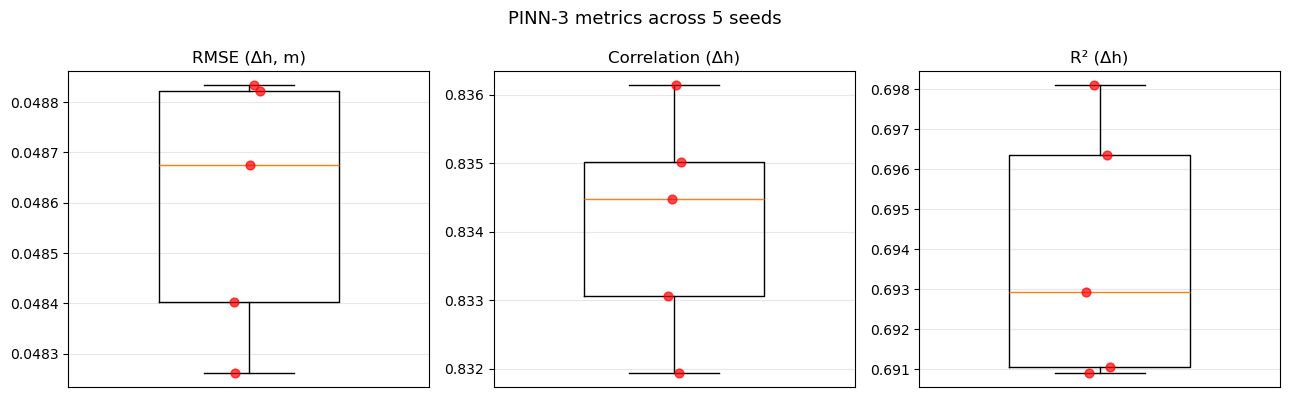

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(
    axes,
    ['rmse_dh', 'corr_dh', 'r2_dh'],
    ['RMSE (Δh, m)', 'Correlation (Δh)', 'R² (Δh)'],
):
    ax.boxplot(df[col].values, vert=True, widths=0.5)
    ax.scatter(np.ones(len(df)) + np.random.uniform(-0.05, 0.05, len(df)),
               df[col].values, color='red', s=40, zorder=3, alpha=0.7)
    ax.set_title(title)
    ax.set_xticks([])
    ax.grid(True, alpha=0.3)

plt.suptitle(f"PINN-3 metrics across {len(SEEDS)} seeds", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'boxplot_metrics.png'), dpi=130, bbox_inches='tight')
plt.show()


### 7.2 Water-level reconstruction — every seed overlaid

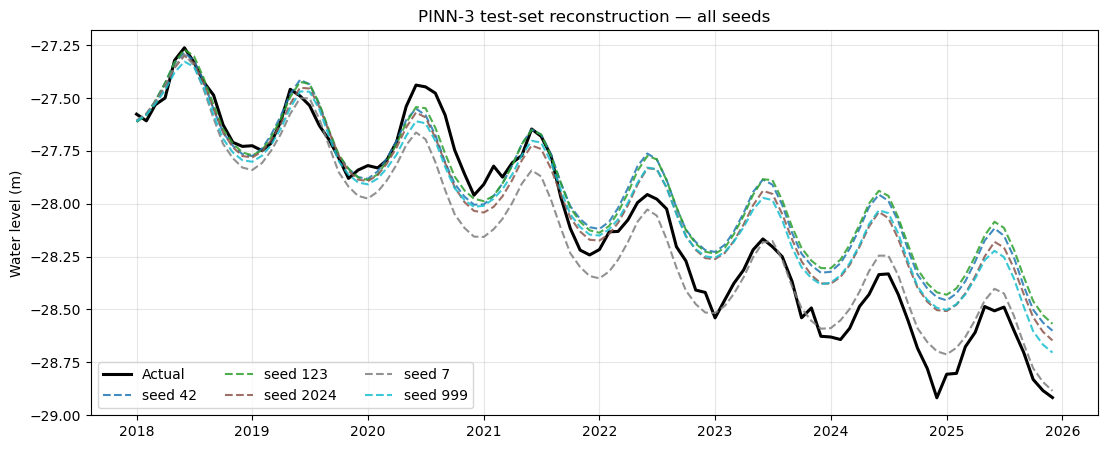

In [11]:
test_times = pd.to_datetime([full_ds.times[full_ds.valid_indices[i]] for i in test_indices])

plt.figure(figsize=(13, 5))
plt.plot(test_times, results[0]['actual_level'],
         label='Actual', color='black', linewidth=2.2)
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for r, c in zip(results, colors):
    plt.plot(test_times, r['pred_level'],
             label=f"seed {r['seed']}", color=c, linestyle='--', alpha=0.85)
plt.title("PINN-3 test-set reconstruction — all seeds")
plt.ylabel("Water level (m)")
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left', ncol=3)
plt.savefig(os.path.join(OUT_DIR, 'reconstruction_all_seeds.png'),
            dpi=130, bbox_inches='tight')
plt.show()


### 7.3 Mean prediction ± std envelope

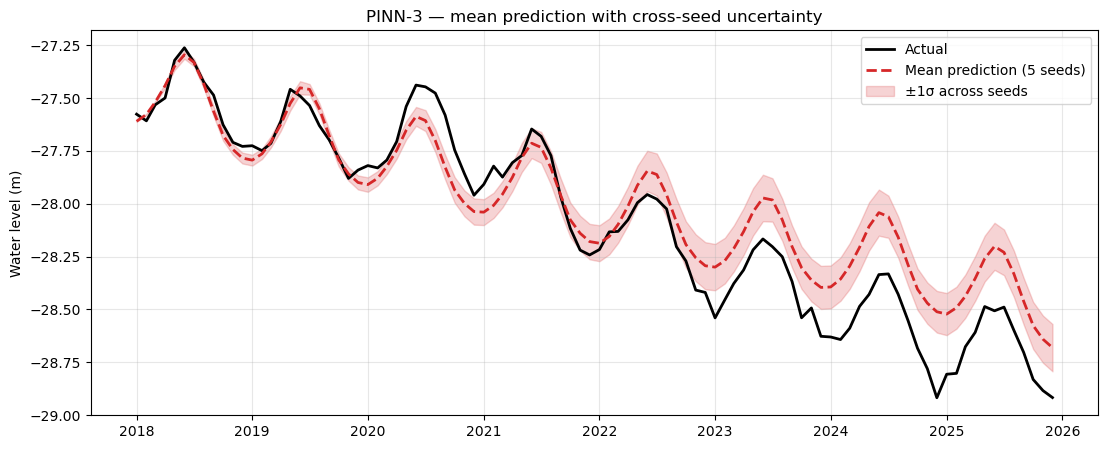

Mean envelope width (2σ): 14.5 cm
Max  envelope width (2σ): 22.8 cm


In [12]:
pred_stack = np.stack([r['pred_level'] for r in results], axis=0)  # (n_seeds, n_steps)
mean_pred  = pred_stack.mean(axis=0)
std_pred   = pred_stack.std(axis=0)

plt.figure(figsize=(13, 5))
plt.plot(test_times, results[0]['actual_level'],
         label='Actual', color='black', linewidth=2)
plt.plot(test_times, mean_pred,
         label=f'Mean prediction ({len(SEEDS)} seeds)',
         color='#d62728', linewidth=2, linestyle='--')
plt.fill_between(test_times, mean_pred - std_pred, mean_pred + std_pred,
                 color='#d62728', alpha=0.2, label='±1σ across seeds')
plt.title("PINN-3 — mean prediction with cross-seed uncertainty")
plt.ylabel("Water level (m)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(os.path.join(OUT_DIR, 'mean_prediction_envelope.png'),
            dpi=130, bbox_inches='tight')
plt.show()

# How wide is the envelope, in centimetres?
print(f"Mean envelope width (2σ): {2*std_pred.mean()*100:.1f} cm")
print(f"Max  envelope width (2σ): {2*std_pred.max() *100:.1f} cm")


### 7.4 Learned physics parameters across seeds

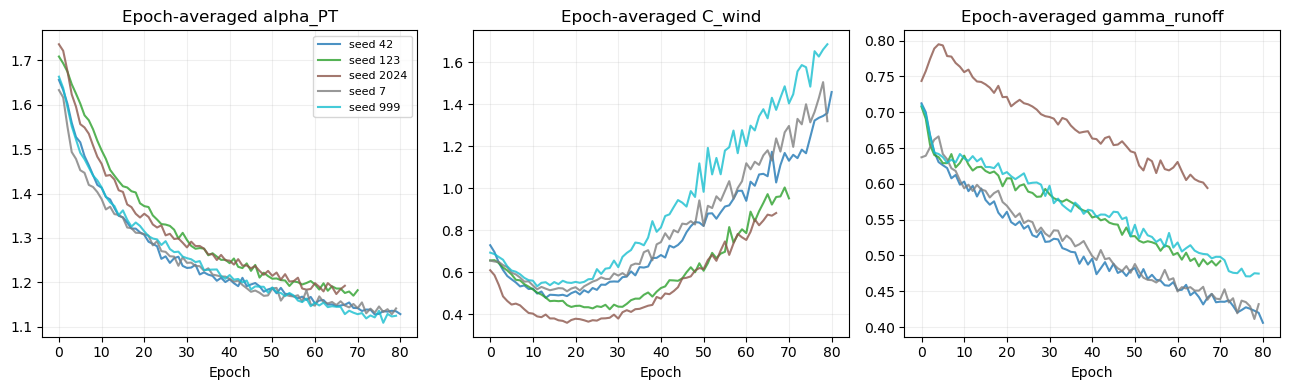

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, key in zip(axes, ['alpha_PT', 'C_wind', 'gamma_runoff']):
    for r, c in zip(results, colors):
        ax.plot(r['history'][key], color=c, alpha=0.8, label=f"seed {r['seed']}")
    ax.set_title(f"Epoch-averaged {key}")
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.2)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'physics_params_all_seeds.png'),
            dpi=130, bbox_inches='tight')
plt.show()


## 8. Final summary — copy-paste into the thesis

Below is a ready-to-paste LaTeX table fragment and the one-line summary you would
write in the discussion.

In [14]:
m_rmse = df['rmse_dh'].mean();   s_rmse = df['rmse_dh'].std()
m_corr = df['corr_dh'].mean();   s_corr = df['corr_dh'].std()
m_r2   = df['r2_dh'].mean();     s_r2   = df['r2_dh'].std()

print("=" * 60)
print(f"PINN-3 cross-seed summary  (n = {len(SEEDS)} seeds)")
print("=" * 60)
print(f"  RMSE (Δh)    : {m_rmse:.4f} ± {s_rmse:.4f}")
print(f"  Correlation  : {m_corr:.4f} ± {s_corr:.4f}")
print(f"  R² (Δh)      : {m_r2:.4f} ± {s_r2:.4f}")
print(f"  R² (level)   : {df['r2_level'].mean():.4f} ± {df['r2_level'].std():.4f}")
print("=" * 60)

print("\n── LaTeX-ready row for Table 4.12 ──")
print(rf"PINN-3 (n={len(SEEDS)} seeds) & Penman/PT & 1 & 1 month & "
      rf"${m_rmse:.4f} \pm {s_rmse:.4f}$ & "
      rf"${m_corr:.4f} \pm {s_corr:.4f}$ & "
      rf"${m_r2:.4f} \pm {s_r2:.4f}$ \\")

# Save JSON summary for the thesis appendix
with open(os.path.join(OUT_DIR, 'final_summary.json'), 'w') as f:
    json.dump({
        'n_seeds'   : len(SEEDS),
        'seeds'     : SEEDS,
        'rmse_dh'   : {'mean': m_rmse, 'std': s_rmse},
        'corr_dh'   : {'mean': m_corr, 'std': s_corr},
        'r2_dh'     : {'mean': m_r2,   'std': s_r2},
        'r2_level'  : {'mean': float(df['r2_level'].mean()),
                       'std':  float(df['r2_level'].std())},
        'rmse_level': {'mean': float(df['rmse_level'].mean()),
                       'std':  float(df['rmse_level'].std())},
        'per_seed'  : df.to_dict(orient='index'),
    }, f, indent=2, default=str)
print(f"\nSaved → {OUT_DIR}/final_summary.json")


PINN-3 cross-seed summary  (n = 5 seeds)
  RMSE (Δh)    : 0.0486 ± 0.0003
  Correlation  : 0.8341 ± 0.0016
  R² (Δh)      : 0.6939 ± 0.0032
  R² (level)   : 0.8194 ± 0.0712

── LaTeX-ready row for Table 4.12 ──
PINN-3 (n=5 seeds) & Penman/PT & 1 & 1 month & $0.0486 \pm 0.0003$ & $0.8341 \pm 0.0016$ & $0.6939 \pm 0.0032$ \\

Saved → results/pinn3_multiseed/final_summary.json


## 9. Interpretation guide for the defence

When you report these numbers, here is the honest framing:

1. **If `std` is small (e.g. RMSE std < 5% of mean)** — the single-run number
   in the current thesis is representative.  The model is stable across
   initialisations.  Defence answer: *"the reported number is the mean of N
   seeds, std = X, so the comparison between PINNs is not noise."*

2. **If `std` is large (e.g. RMSE std comparable to the gap between PINN
   variants)** — that is itself the important result.  Defence answer:
   *"differences between PINN-1, PINN-2 and PINN-3 of order Y are within
   the seed-to-seed variance, so we should not over-interpret the
   ranking."*  This is actually more scientifically defensible than claiming
   a single best model.

3. **Where to put this in the thesis:** add a new subsection `4.5.X
   Multi-Seed Stability Analysis` after the regime-shift discussion and
   before the Conclusion.  Reference the boxplot and the mean ± std table.
   In the Conclusion, replace "PINN-3 achieved correlation 0.8279" with
   "PINN-3 achieved correlation 0.83 ± std (n = N seeds)".

This experiment closes the most dangerous defence question — *"how do you
know one seed is representative?"* — without changing any other part of the
analysis.